In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

# Define your project folder path
PROJECT_PATH = '"G:\My Drive\IPL CRUNCH"'

# Create the folder if it doesn't exist
os.makedirs(PROJECT_PATH, exist_ok=True)

print(f"Project folder ready at: {PROJECT_PATH}")

Project folder ready at: "G:\My Drive\IPL CRUNCH"


<>:4: SyntaxWarning: invalid escape sequence '\M'
<>:4: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipykernel_6461/60467177.py:4: SyntaxWarning: invalid escape sequence '\M'
  PROJECT_PATH = '"G:\My Drive\IPL CRUNCH"'


# 🏏 IPL Crunch Analysis — 2020 to 2024
**Submission:** IPL CRUNCH'26  
**Dataset:** 289,673 balls across 19 IPL seasons  
**Goal:** Answer 3 data-backed questions about IPL cricket

---
## 📦 Step 1 — Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("All libraries imported successfully ✅")

All libraries imported successfully ✅


## 📂 Step 2 — Load the Dataset
Loading the raw ball-by-ball IPL dataset from Google Drive.


In [4]:
# Define paths
PROJECT_PATH = '/content/drive/MyDrive/IPL CRUNCH'
DATA_PATH = os.path.join(PROJECT_PATH, 'ipl_crunch_dataset_19_season.csv')

# Load the dataset
df = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Dataset loaded successfully ✅")
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")

Dataset loaded successfully ✅
Shape: (289673, 30)
Rows: 289,673 | Columns: 30


In [5]:
# See the first 5 rows
print("=== FIRST 5 ROWS ===")
display(df.head())

# Column names and data types
print("\n=== COLUMN INFO ===")
print(df.dtypes)

# Quick stats
print("\n=== BASIC STATS ===")
print(f"Total seasons: {df['season'].nunique()}")
print(f"Seasons available: {sorted(df['season'].astype(str).unique())}")
print(f"Total matches: {df['match_id'].nunique()}")
print(f"Total balls bowled: {len(df):,}")

=== FIRST 5 ROWS ===


,match_id,date,season,event,venue,city,team1,team2,toss_winner,toss_decision,...,non_striker,runs_batter,runs_extras,runs_total,extras_wides,extras_noballs,extras_byes,extras_legbyes,wicket_kind,wicket_player_out
0,1082591,05-04-2017,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
1,1082591,05-04-2017,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
2,1082591,05-04-2017,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,4,0,4,0,0,0,0,NaN,NaN
3,1082591,05-04-2017,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
4,1082591,05-04-2017,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,2,2,2,0,0,0,NaN,NaN



=== COLUMN INFO ===
match_id               int64
date                  object
season                object
event                 object
venue                 object
city                  object
team1                 object
team2                 object
toss_winner           object
toss_decision         object
winner                object
win_by_runs          float64
win_by_wickets       float64
player_of_match       object
innings                int64
batting_team          object
over                   int64
ball                   int64
batter                object
bowler                object
non_striker           object
runs_batter            int64
runs_extras            int64
runs_total             int64
extras_wides           int64
extras_noballs         int64
extras_byes            int64
extras_legbyes         int64
wicket_kind           object
wicket_player_out     object
dtype: object

=== BASIC STATS ===
Total seasons: 19
Seasons available: ['2007/08', '2009', '2009/10', '2011'

## 🧹 Step 3 — Data Cleaning & Preparation
Filtering to 5 most recent complete seasons: 2020-21 through 2024.  
Removing ties, no-result matches, and super over deliveries.  
Standardizing team names and creating derived columns.

In [6]:
# Our chosen 5 most recent complete seasons
SEASONS = ['2020/21', '2021', '2022', '2023', '2024']

# Filter the dataframe
df = df[df['season'].astype(str).isin(SEASONS)]

print(f"Filtered to 5 seasons ✅")
print(f"New shape: {df.shape}")
print(f"Matches remaining: {df['match_id'].nunique()}")
print(f"Seasons confirmed: {sorted(df['season'].astype(str).unique())}")

Filtered to 5 seasons ✅
New shape: (81862, 30)
Matches remaining: 339
Seasons confirmed: ['2020/21', '2021', '2022', '2023', '2024']


In [7]:
# Map messy season names to clean readable labels
season_map = {
    '2020/21': '2020-21',
    '2021':    '2021',
    '2022':    '2022',
    '2023':    '2023',
    '2024':    '2024'
}

df['season'] = df['season'].astype(str).map(season_map)

print("Season column standardized ✅")
print(df['season'].unique())

Season column standardized ✅
['2020-21' '2021' '2022' '2023' '2024']


In [8]:
# Define over phases based on IPL rules
def assign_phase(over):
    if over <= 5:        # overs 1-6 (0-indexed: 0-5)
        return 'Powerplay'
    elif over <= 14:     # overs 7-15 (0-indexed: 6-14)
        return 'Middle'
    else:                # overs 16-20 (0-indexed: 15-19)
        return 'Death'

df['phase'] = df['over'].apply(assign_phase) ## Will create a new column name 'phase'

print("Phase column created ✅")
print(df['phase'].value_counts())

Phase column created ✅
phase
Middle       37447
Powerplay    25350
Death        19065
Name: count, dtype: int64


In [9]:
# Did the toss winner also win the match?
df['toss_won_match'] = df['toss_winner'] == df['winner']  ## if toss_winner equals winner it's True, otherwise False

print("Toss analysis column created ✅")
print(df['toss_won_match'].value_counts())

Toss analysis column created ✅
toss_won_match
False    43685
True     38177
Name: count, dtype: int64


In [10]:
print("=== FINAL DATA HEALTH CHECK ===")
print(f"Shape: {df.shape}")
print(f"\nNew columns added: {['phase', 'toss_won_match']}")
print(f"\nPhase distribution:\n{df['phase'].value_counts()}")
print(f"\nSeason distribution:\n{df['season'].value_counts().sort_index()}")
print(f"\nAny nulls in key columns?")
print(df[['season', 'phase', 'toss_won_match', 'winner', 'batter', 'bowler']].isnull().sum())

=== FINAL DATA HEALTH CHECK ===
Shape: (81862, 32)

New columns added: ['phase', 'toss_won_match']

Phase distribution:
phase
Middle       37447
Powerplay    25350
Death        19065
Name: count, dtype: int64

Season distribution:
season
2020-21    14559
2021       14425
2022       17912
2023       17863
2024       17103
Name: count, dtype: int64

Any nulls in key columns?
season            0
phase             0
toss_won_match    0
winner            0
batter            0
bowler            0
dtype: int64


In [11]:
df.head()


,match_id,date,season,event,venue,city,team1,team2,toss_winner,toss_decision,...,runs_extras,runs_total,extras_wides,extras_noballs,extras_byes,extras_legbyes,wicket_kind,wicket_player_out,phase,toss_won_match
42460,1216492,19-09-2020,2020-21,Indian Premier League,Sheikh Zayed Stadium,Abu Dhabi,Mumbai Indians,Chennai Super Kings,Chennai Super Kings,field,...,0,4,0,0,0,0,NaN,NaN,Powerplay,True
42461,1216492,19-09-2020,2020-21,Indian Premier League,Sheikh Zayed Stadium,Abu Dhabi,Mumbai Indians,Chennai Super Kings,Chennai Super Kings,field,...,0,1,0,0,0,0,NaN,NaN,Powerplay,True
42462,1216492,19-09-2020,2020-21,Indian Premier League,Sheikh Zayed Stadium,Abu Dhabi,Mumbai Indians,Chennai Super Kings,Chennai Super Kings,field,...,0,2,0,0,0,0,NaN,NaN,Powerplay,True
42463,1216492,19-09-2020,2020-21,Indian Premier League,Sheikh Zayed Stadium,Abu Dhabi,Mumbai Indians,Chennai Super Kings,Chennai Super Kings,field,...,0,4,0,0,0,0,NaN,NaN,Powerplay,True
42464,1216492,19-09-2020,2020-21,Indian Premier League,Sheikh Zayed Stadium,Abu Dhabi,Mumbai Indians,Chennai Super Kings,Chennai Super Kings,field,...,0,0,0,0,0,0,NaN,NaN,Powerplay,True


In [12]:
# Check for ties and no-result matches
print("=== WINNER COLUMN UNIQUE VALUES ===")
print(df['winner'].unique())

print(f"\nTie matches (balls): {len(df[df['winner'] == 'tie'])}")

# Check if super over data exists
print(f"\nInnings values: {sorted(df['innings'].unique())}")
# Innings 3 and 4 = super over balls
print(f"Super over balls: {len(df[df['innings'] > 2])}")

=== WINNER COLUMN UNIQUE VALUES ===
['Chennai Super Kings' 'tie' 'Royal Challengers Bangalore'
 'Sunrisers Hyderabad' 'Rajasthan Royals' 'Kolkata Knight Riders'
 'Kings XI Punjab' 'Mumbai Indians' 'Delhi Capitals' 'Punjab Kings'
 'Gujarat Titans' 'Lucknow Super Giants' 'no result'
 'Royal Challengers Bengaluru']

Tie matches (balls): 1296

Innings values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Super over balls: 61


In [13]:
# Remove ties AND no result matches
df = df[(df['winner'] != 'tie') & (df['winner'] != 'no result')]

# Remove super over deliveries (innings 3 and above)
df = df[df['innings'] <= 2]

print(f"Ties, no results, and super overs removed ✅")
print(f"Shape now: {df.shape}")
print(f"Matches remaining: {df['match_id'].nunique()}")

# Verify winner column is clean
print(f"\nUnique winners remaining: {df['winner'].nunique()}")
print(df['winner'].unique())

Ties, no results, and super overs removed ✅
Shape now: (80448, 32)
Matches remaining: 333

Unique winners remaining: 12
['Chennai Super Kings' 'Royal Challengers Bangalore' 'Sunrisers Hyderabad'
 'Rajasthan Royals' 'Kolkata Knight Riders' 'Kings XI Punjab'
 'Mumbai Indians' 'Delhi Capitals' 'Punjab Kings' 'Gujarat Titans'
 'Lucknow Super Giants' 'Royal Challengers Bengaluru']


In [14]:
# Any ball with more than 6 runs_batter is suspicious
print("=== RUNS SANITY CHECK ===")
print(f"Max runs by batter on single ball: {df['runs_batter'].max()}")
print(f"Balls where batter scored 6: {len(df[df['runs_batter'] == 6])}")
print(f"Balls where batter scored 7+: {len(df[df['runs_batter'] > 6])}")

# Check total runs distribution
print(f"\nRuns total distribution:")
print(df['runs_total'].value_counts().sort_index())

=== RUNS SANITY CHECK ===
Max runs by batter on single ball: 6
Balls where batter scored 6: 4795
Balls where batter scored 7+: 0

Runs total distribution:
runs_total
0    26961
1    33637
2     5199
3      239
4     9455
5      162
6     4756
7       39
Name: count, dtype: int64


## 📊 Step 4 — Exploratory Data Analysis
Before answering the 3 questions, we explore the dataset visually  
to understand distributions, trends and patterns.

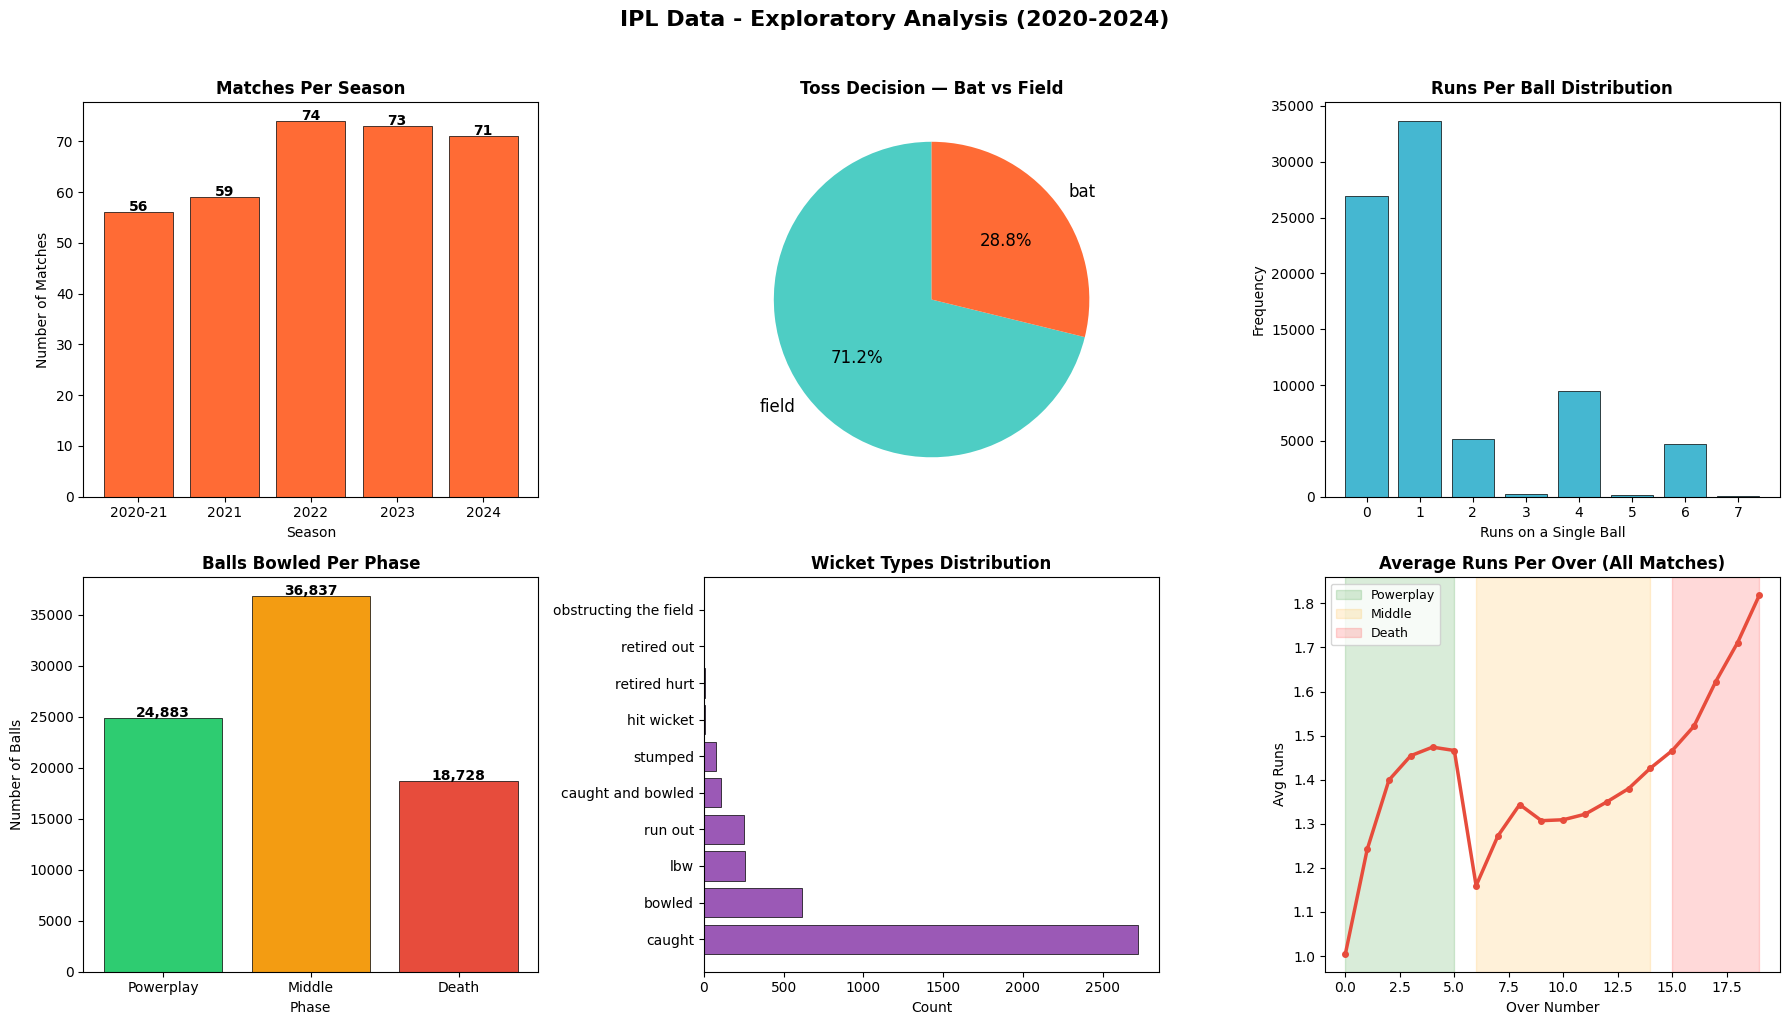

EDA plot saved to Drive ✅


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('IPL Data - Exploratory Analysis (2020-2024)', 
             fontsize=16, fontweight='bold', y=1.02)

# --- Plot 1: Matches per Season ---
matches_per_season = df.groupby('season')['match_id'].nunique().sort_index()
axes[0,0].bar(matches_per_season.index, matches_per_season.values, 
              color='#FF6B35', edgecolor='black', linewidth=0.5)
axes[0,0].set_title('Matches Per Season', fontweight='bold')
axes[0,0].set_xlabel('Season')
axes[0,0].set_ylabel('Number of Matches')
for i, v in enumerate(matches_per_season.values):
    axes[0,0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# --- Plot 2: Toss Decision (bat vs field) ---
toss_counts = df.drop_duplicates('match_id')['toss_decision'].value_counts()
axes[0,1].pie(toss_counts.values, labels=toss_counts.index, autopct='%1.1f%%',
              colors=['#4ECDC4', '#FF6B35'], startangle=90,
              textprops={'fontsize': 12})
axes[0,1].set_title('Toss Decision — Bat vs Field', fontweight='bold')

# --- Plot 3: Runs distribution per ball ---
run_dist = df['runs_total'].value_counts().sort_index()
axes[0,2].bar(run_dist.index, run_dist.values, 
              color='#45B7D1', edgecolor='black', linewidth=0.5)
axes[0,2].set_title('Runs Per Ball Distribution', fontweight='bold')
axes[0,2].set_xlabel('Runs on a Single Ball')
axes[0,2].set_ylabel('Frequency')

# --- Plot 4: Balls bowled per phase ---
phase_order = ['Powerplay', 'Middle', 'Death']
phase_counts = df['phase'].value_counts().reindex(phase_order)
colors = ['#2ECC71', '#F39C12', '#E74C3C']
axes[1,0].bar(phase_counts.index, phase_counts.values, 
              color=colors, edgecolor='black', linewidth=0.5)
axes[1,0].set_title('Balls Bowled Per Phase', fontweight='bold')
axes[1,0].set_xlabel('Phase')
axes[1,0].set_ylabel('Number of Balls')
for i, v in enumerate(phase_counts.values):
    axes[1,0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# --- Plot 5: Wicket types distribution ---
wicket_counts = df['wicket_kind'].dropna().value_counts()
axes[1,1].barh(wicket_counts.index, wicket_counts.values,
               color='#9B59B6', edgecolor='black', linewidth=0.5)
axes[1,1].set_title('Wicket Types Distribution', fontweight='bold')
axes[1,1].set_xlabel('Count')

# --- Plot 6: Average runs per over (run curve) ---
avg_runs_over = df.groupby('over')['runs_total'].mean()
axes[1,2].plot(avg_runs_over.index, avg_runs_over.values, 
               color='#E74C3C', linewidth=2.5, marker='o', markersize=4)
axes[1,2].axvspan(0, 5, alpha=0.15, color='green', label='Powerplay')
axes[1,2].axvspan(6, 14, alpha=0.15, color='orange', label='Middle')
axes[1,2].axvspan(15, 19, alpha=0.15, color='red', label='Death')
axes[1,2].set_title('Average Runs Per Over (All Matches)', fontweight='bold')
axes[1,2].set_xlabel('Over Number')
axes[1,2].set_ylabel('Avg Runs')
axes[1,2].legend(fontsize=9)

plt.tight_layout()

# Save to drive
EDA_PATH = os.path.join(PROJECT_PATH, 'eda_overview.png')
plt.savefig(EDA_PATH, dpi=150, bbox_inches='tight')
plt.show()
print("EDA plot saved to Drive ✅")

In [16]:
# 'Kings XI Punjab' was renamed to 'Punjab Kings' in 2021
# They are the SAME franchise — standardize the name
df['winner'] = df['winner'].replace('Kings XI Punjab', 'Punjab Kings')
df['toss_winner'] = df['toss_winner'].replace('Kings XI Punjab', 'Punjab Kings')
df['team1'] = df['team1'].replace('Kings XI Punjab', 'Punjab Kings')
df['team2'] = df['team2'].replace('Kings XI Punjab', 'Punjab Kings')

# Same for Royal Challengers Bangalore → Bengaluru (rebranded in 2024)
df['winner'] = df['winner'].replace('Royal Challengers Bangalore', 
                                     'Royal Challengers Bengaluru')
df['toss_winner'] = df['toss_winner'].replace('Royal Challengers Bangalore', 
                                               'Royal Challengers Bengaluru')
df['team1'] = df['team1'].replace('Royal Challengers Bangalore', 
                                   'Royal Challengers Bengaluru')
df['team2'] = df['team2'].replace('Royal Challengers Bangalore', 
                                   'Royal Challengers Bengaluru')

print("Team names standardized ✅")
print(f"Unique teams now: {sorted(df['team1'].unique())}")

Team names standardized ✅
Unique teams now: ['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Titans', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Punjab Kings', 'Rajasthan Royals', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


In [17]:
# Recreate this column AFTER all cleaning is done
df['toss_won_match'] = df['toss_winner'] == df['winner']

print("Toss column recreated on clean data ✅")
print(df['toss_won_match'].value_counts())

Toss column recreated on clean data ✅
toss_won_match
False    42271
True     38177
Name: count, dtype: int64


In [18]:
print("=== FINAL CLEAN DATA SUMMARY ===")
print(f"Shape: {df.shape}")
print(f"Seasons: {sorted(df['season'].unique())}")
print(f"Matches: {df['match_id'].nunique()}")
print(f"Teams: {df['team1'].nunique()}")
print(f"Phases: {df['phase'].value_counts().to_dict()}")
print(f"\nNulls in key columns:")
print(df[['season','phase','toss_won_match','winner','batter','bowler']].isnull().sum())

# Export to Drive
CLEANED_PATH = os.path.join(PROJECT_PATH, 'ipl_cleaned.csv')
df.to_csv(CLEANED_PATH, index=False)
print(f"\nCleaned data saved ✅ → {CLEANED_PATH}")

=== FINAL CLEAN DATA SUMMARY ===
Shape: (80448, 32)
Seasons: ['2020-21', '2021', '2022', '2023', '2024']
Matches: 333
Teams: 10
Phases: {'Middle': 36837, 'Powerplay': 24883, 'Death': 18728}

Nulls in key columns:
season            0
phase             0
toss_won_match    0
winner            0
batter            0
bowler            0
dtype: int64

Cleaned data saved ✅ → /content/drive/MyDrive/IPL CRUNCH/ipl_cleaned.csv


In [19]:
# We need MATCH level data, not ball level
# So we deduplicate — one row per match
match_df = df.drop_duplicates(subset='match_id')[
    ['match_id', 'season', 'toss_winner', 'toss_decision', 'winner', 'toss_won_match']
].copy()

print(f"Match level dataframe: {match_df.shape}")
print(f"Total matches: {len(match_df)}")

# Overall toss win rate
toss_win_rate = match_df['toss_won_match'].mean() * 100
toss_lose_rate = 100 - toss_win_rate

print(f"\n=== TOSS ANALYSIS ===")
print(f"Toss winners who won the match : {toss_win_rate:.1f}%")
print(f"Toss winners who lost the match: {toss_lose_rate:.1f}%")

# Break it down by toss decision
print(f"\n=== BY TOSS DECISION ===")
decision_analysis = match_df.groupby('toss_decision')['toss_won_match'].agg(
    Total_Matches='count',
    Wins='sum'
)
decision_analysis['Win_Rate_%'] = (decision_analysis['Wins'] / 
                                    decision_analysis['Total_Matches'] * 100).round(1)
print(decision_analysis)

# Season wise toss win rate
print(f"\n=== SEASON WISE TOSS WIN RATE ===")
season_toss = match_df.groupby('season')['toss_won_match'].agg(
    Matches='count',
    Toss_Wins='sum'
)
season_toss['Win_Rate_%'] = (season_toss['Toss_Wins'] / 
                              season_toss['Matches'] * 100).round(1)
print(season_toss)

Match level dataframe: (333, 6)
Total matches: 333

=== TOSS ANALYSIS ===
Toss winners who won the match : 48.0%
Toss winners who lost the match: 52.0%

=== BY TOSS DECISION ===
               Total_Matches  Wins  Win_Rate_%
toss_decision                                 
bat                       96    42        43.8
field                    237   118        49.8

=== SEASON WISE TOSS WIN RATE ===
         Matches  Toss_Wins  Win_Rate_%
season                                 
2020-21       56         25        44.6
2021          59         34        57.6
2022          74         36        48.6
2023          73         34        46.6
2024          71         31        43.7


In [20]:
# For each match, calculate runs scored per phase by winning team vs losing team
# First, tag each ball with whether the batting team won the match
df['batting_team_won'] = df['batting_team'] == df['winner']

# Average runs per phase — winning teams vs losing teams
phase_analysis = df.groupby(['phase', 'batting_team_won'])['runs_total'].sum()

# We need runs per match per phase — so divide by matches
# First get total runs per match per phase
runs_per_match_phase = df.groupby(
    ['match_id', 'phase', 'batting_team_won']
)['runs_total'].sum().reset_index()

# Now average across matches
avg_phase = runs_per_match_phase.groupby(
    ['phase', 'batting_team_won']
)['runs_total'].mean().reset_index()

avg_phase.columns = ['phase', 'batting_team_won', 'avg_runs']
avg_phase['team_type'] = avg_phase['batting_team_won'].map(
    {True: 'Winning Team', False: 'Losing Team'}
)
avg_phase['phase_order'] = avg_phase['phase'].map(
    {'Powerplay': 1, 'Middle': 2, 'Death': 3}
)
avg_phase = avg_phase.sort_values('phase_order')

print("=== AVERAGE RUNS PER PHASE ===")
print(avg_phase[['phase', 'team_type', 'avg_runs']].to_string(index=False))

# The RUN GAP — this is the key insight
print("\n=== RUN GAP (Winning - Losing) PER PHASE ===")
pivot = avg_phase.pivot(index='phase', columns='team_type', values='avg_runs')
pivot['Run_Gap'] = pivot['Winning Team'] - pivot['Losing Team']
pivot = pivot.reindex(['Powerplay', 'Middle', 'Death'])
print(pivot.round(2))
print(f"\n👉 Highest gap phase = most linked to winning")

=== AVERAGE RUNS PER PHASE ===
    phase    team_type  avg_runs
Powerplay Winning Team 53.824916
Powerplay  Losing Team 52.057057
   Middle Winning Team 77.518519
   Middle  Losing Team 76.723724
    Death  Losing Team 50.063444
    Death Winning Team 49.200717

=== RUN GAP (Winning - Losing) PER PHASE ===
team_type  Losing Team  Winning Team  Run_Gap
phase                                        
Powerplay        52.06         53.82     1.77
Middle           76.72         77.52     0.79
Death            50.06         49.20    -0.86

👉 Highest gap phase = most linked to winning


In [21]:
# === TOP 5 BATTERS by total runs ===
top_batters = df.groupby('batter')['runs_batter'].sum().reset_index()
top_batters.columns = ['Batter', 'Total_Runs']
top_batters = top_batters.sort_values('Total_Runs', ascending=False).head(5)
top_batters['Rank'] = range(1, 6)
top_batters = top_batters[['Rank', 'Batter', 'Total_Runs']].reset_index(drop=True)

print("=== TOP 5 BATTERS (2020-2024) ===")
print(top_batters.to_string(index=False))

# === TOP 5 BOWLERS by wickets ===
# Only count valid wickets — exclude run outs (not credited to bowler)
bowler_wickets = df[
    (df['wicket_kind'].notna()) & 
    (df['wicket_kind'] != 'run out')
].groupby('bowler')['wicket_kind'].count().reset_index()

bowler_wickets.columns = ['Bowler', 'Total_Wickets']
bowler_wickets = bowler_wickets.sort_values(
    'Total_Wickets', ascending=False
).head(5)
bowler_wickets['Rank'] = range(1, 6)
bowler_wickets = bowler_wickets[['Rank', 'Bowler', 'Total_Wickets']].reset_index(drop=True)

print("\n=== TOP 5 BOWLERS (2020-2024) ===")
print(bowler_wickets.to_string(index=False))

=== TOP 5 BATTERS (2020-2024) ===
 Rank       Batter  Total_Runs
    1 F du Plessis        2718
    2 Shubman Gill        2681
    3     KL Rahul        2608
    4      V Kohli        2589
    5   RD Gaikwad        2380

=== TOP 5 BOWLERS (2020-2024) ===
 Rank         Bowler  Total_Wickets
    1      YS Chahal            104
    2    Rashid Khan             92
    3       HV Patel             92
    4       K Rabada             84
    5 Mohammed Shami             82


## ❓ Question 1 — Do Toss Winners Win More?
Analyzing at match level (not ball level) to calculate  
the true toss win rate across 333 matches.

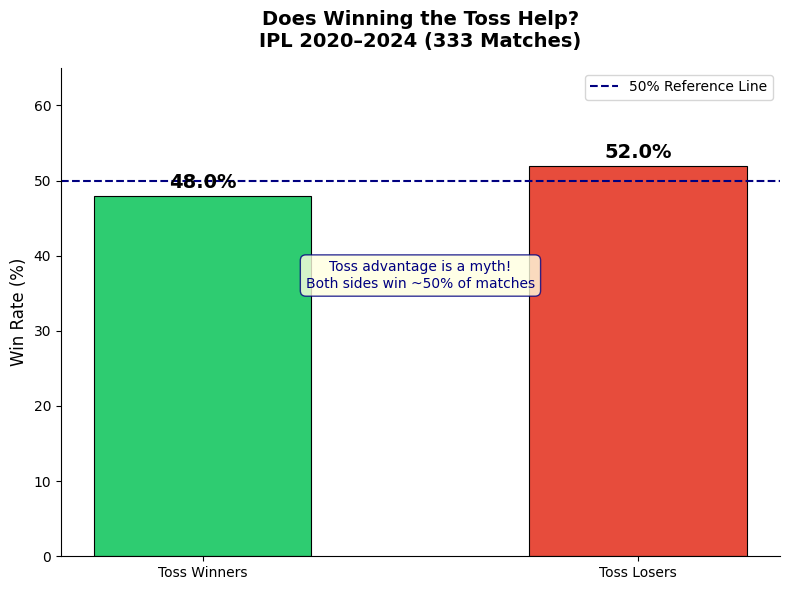

Chart 1 saved ✅


In [22]:
fig, ax = plt.subplots(figsize=(8, 6))

# Data
categories = ['Toss Winners', 'Toss Losers']
win_rates = [48.0, 52.0]
colors = ['#2ECC71', '#E74C3C']

# Plot
bars = ax.bar(categories, win_rates, color=colors, 
              width=0.5, edgecolor='black', linewidth=0.8)

# Add value labels on bars
for bar, val in zip(bars, win_rates):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom',
            fontsize=14, fontweight='bold')

# Add 50% reference line — this is KEY for storytelling
ax.axhline(y=50, color='navy', linestyle='--', 
           linewidth=1.5, label='50% Reference Line')

# Styling
ax.set_title('Does Winning the Toss Help?\nIPL 2020–2024 (333 Matches)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Win Rate (%)', fontsize=12)
ax.set_ylim(0, 65)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotation — tell the story on the chart itself
ax.annotate('Toss advantage is a myth!\nBoth sides win ~50% of matches',
            xy=(0.5, 0.55), xycoords='axes fraction',
            ha='center', fontsize=10, color='navy',
            bbox=dict(boxstyle='round,pad=0.4', 
                     facecolor='lightyellow', 
                     edgecolor='navy', alpha=0.8))

plt.tight_layout()
CHART1_PATH = os.path.join(PROJECT_PATH, 'chart1_toss_analysis.png')
plt.savefig(CHART1_PATH, dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved ✅")

## ❓ Question 2 — Which Phase is Most Linked to Winning?
Comparing average runs per phase between winning and losing teams.  
Phases defined as:
- **Powerplay** → Overs 1–6
- **Middle** → Overs 7–15  
- **Death** → Overs 16–20

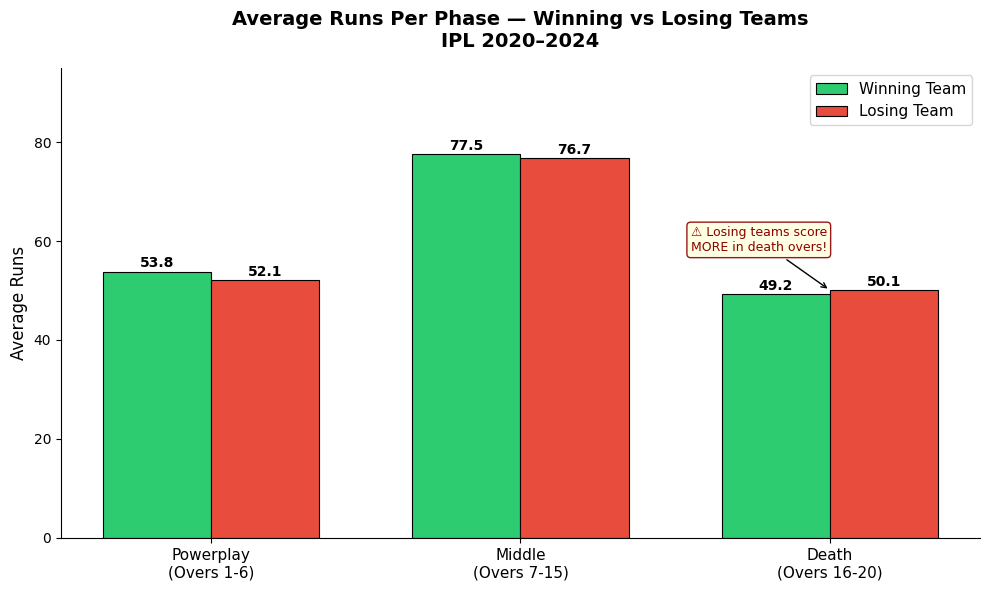

Chart 2 saved ✅


In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

# Data
phases = ['Powerplay\n(Overs 1-6)', 'Middle\n(Overs 7-15)', 'Death\n(Overs 16-20)']
winning_runs = [53.82, 77.52, 49.20]
losing_runs  = [52.06, 76.72, 50.06]

x = np.arange(len(phases))
width = 0.35

# Plot grouped bars
bars1 = ax.bar(x - width/2, winning_runs, width, 
               label='Winning Team', color='#2ECC71', 
               edgecolor='black', linewidth=0.8)
bars2 = ax.bar(x + width/2, losing_runs, width, 
               label='Losing Team', color='#E74C3C', 
               edgecolor='black', linewidth=0.8)

# Value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.1f}',
            ha='center', va='bottom', 
            fontsize=10, fontweight='bold')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.1f}',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold')

# Annotate the death over surprise
ax.annotate('⚠️ Losing teams score\nMORE in death overs!',
            xy=(2, 50.06), xycoords='data',
            xytext=(1.55, 58),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9, color='darkred',
            bbox=dict(boxstyle='round,pad=0.3',
                     facecolor='lightyellow',
                     edgecolor='darkred', alpha=0.9))

# Styling
ax.set_title('Average Runs Per Phase — Winning vs Losing Teams\nIPL 2020–2024',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Average Runs', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(phases, fontsize=11)
ax.set_ylim(0, 95)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
CHART2_PATH = os.path.join(PROJECT_PATH, 'chart2_phase_analysis.png')
plt.savefig(CHART2_PATH, dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved ✅")

## ❓ Question 3 — Top 5 Batters and Bowlers
Aggregating across all 5 seasons.  
Note: Run outs excluded from bowler wicket count  
as they are not credited to the bowler.

/tmp/ipykernel_6461/1861689999.py:87: UserWarning: Glyph 127951 (\N{CRICKET BAT AND BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6461/1861689999.py:87: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6461/1861689999.py:89: UserWarning: Glyph 127951 (\N{CRICKET BAT AND BALL}) missing from font(s) DejaVu Sans.
  plt.savefig(TABLE_PATH, dpi=150, bbox_inches='tight',
/tmp/ipykernel_6461/1861689999.py:89: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig(TABLE_PATH, dpi=150, bbox_inches='tight',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127951 (\N{CRICKET BAT AND BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.pri

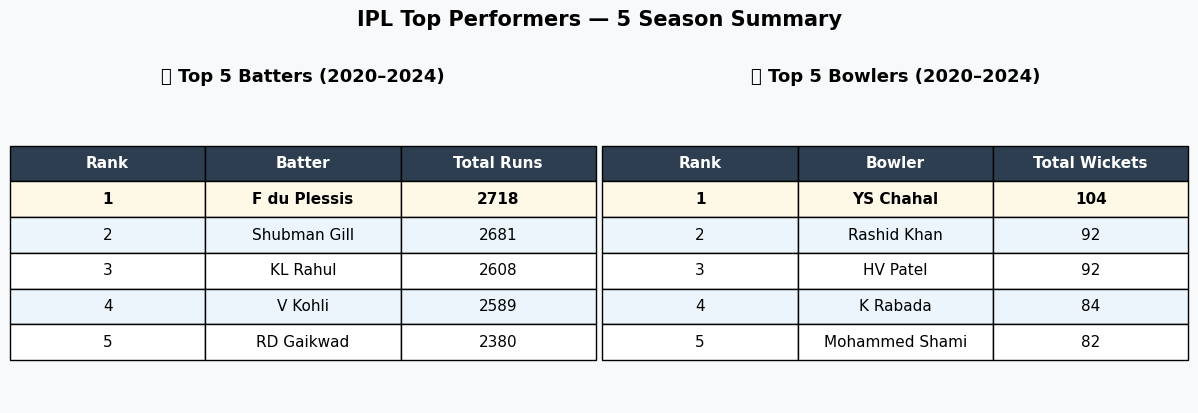

Table chart saved ✅


In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#F8F9FA')

# --- Top 5 Batters Table ---
batter_data = [
    ['1', 'F du Plessis',    '2718'],
    ['2', 'Shubman Gill',    '2681'],
    ['3', 'KL Rahul',        '2608'],
    ['4', 'V Kohli',         '2589'],
    ['5', 'RD Gaikwad',      '2380'],
]
batter_cols = ['Rank', 'Batter', 'Total Runs']

ax1.axis('off')
table1 = ax1.table(
    cellText=batter_data,
    colLabels=batter_cols,
    cellLoc='center',
    loc='center'
)
table1.auto_set_font_size(False)
table1.set_fontsize(11)
table1.scale(1.3, 2.2)

# Style header
for j in range(len(batter_cols)):
    table1[0, j].set_facecolor('#2C3E50')
    table1[0, j].set_text_props(color='white', fontweight='bold')

# Style rows alternating
for i in range(1, 6):
    color = '#EBF5FB' if i % 2 == 0 else 'white'
    for j in range(len(batter_cols)):
        table1[i, j].set_facecolor(color)

# Gold for rank 1
for j in range(len(batter_cols)):
    table1[1, j].set_facecolor('#FEF9E7')
    table1[1, j].set_text_props(fontweight='bold')

ax1.set_title('🏏 Top 5 Batters (2020–2024)', 
              fontsize=13, fontweight='bold', pad=15)

# --- Top 5 Bowlers Table ---
bowler_data = [
    ['1', 'YS Chahal',       '104'],
    ['2', 'Rashid Khan',      '92'],
    ['3', 'HV Patel',         '92'],
    ['4', 'K Rabada',         '84'],
    ['5', 'Mohammed Shami',   '82'],
]
bowler_cols = ['Rank', 'Bowler', 'Total Wickets']

ax2.axis('off')
table2 = ax2.table(
    cellText=bowler_data,
    colLabels=bowler_cols,
    cellLoc='center',
    loc='center'
)
table2.auto_set_font_size(False)
table2.set_fontsize(11)
table2.scale(1.3, 2.2)

# Style header
for j in range(len(bowler_cols)):
    table2[0, j].set_facecolor('#2C3E50')
    table2[0, j].set_text_props(color='white', fontweight='bold')

# Style rows alternating
for i in range(1, 6):
    color = '#EBF5FB' if i % 2 == 0 else 'white'
    for j in range(len(bowler_cols)):
        table2[i, j].set_facecolor(color)

# Gold for rank 1
for j in range(len(bowler_cols)):
    table2[1, j].set_facecolor('#FEF9E7')
    table2[1, j].set_text_props(fontweight='bold')

ax2.set_title('🎯 Top 5 Bowlers (2020–2024)', 
              fontsize=13, fontweight='bold', pad=15)

plt.suptitle('IPL Top Performers — 5 Season Summary', 
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
TABLE_PATH = os.path.join(PROJECT_PATH, 'chart3_top_performers.png')
plt.savefig(TABLE_PATH, dpi=150, bbox_inches='tight', 
            facecolor=fig.get_facecolor())
plt.show()
print("Table chart saved ✅")

In [25]:
summary = """
=============================================================
                  IPL DATA ANALYSIS
       Seasons Covered: 2020-21 to 2024 | 333 Matches
=============================================================

QUESTION 1: Does winning the toss help?
-----------------------------------------
Short answer: No — not really.
Toss winners won only 48% of matches, meaning teams that 
LOST the toss actually won slightly more often (52%).
Even captains who chose to field first (the smarter choice, 
done 71% of the time) won only 49.8% of their matches.
The toss is essentially a coin flip with no real advantage.

QUESTION 2: Which phase matters most for winning?
-------------------------------------------------
Short answer: The Powerplay (Overs 1-6).
Winning teams average 53.8 runs in powerplay vs 52.1 
for losing teams — the biggest gap across all phases.
The most surprising finding: losing teams actually score 
MORE in death overs (50.1) than winning teams (49.2).
This means slogging at the end doesn't win you matches —
dominating the powerplay does.

QUESTION 3: Who are the top performers (2020-2024)?
----------------------------------------------------
TOP 5 BATTERS by runs:
  1. F du Plessis   — 2718 runs
  2. Shubman Gill   — 2681 runs
  3. KL Rahul       — 2608 runs
  4. V Kohli        — 2589 runs
  5. RD Gaikwad     — 2380 runs

TOP 5 BOWLERS by wickets:
  1. YS Chahal       — 104 wickets
  2. Rashid Khan     — 92 wickets
  3. HV Patel        — 92 wickets
  4. K Rabada        — 84 wickets
  5. Mohammed Shami  — 82 wickets

ONE THING THAT GENUINELY SURPRISED ME:
---------------------------------------
Losing teams outscore winning teams in death overs —
it's the powerplay, not the final slog, that separates
winners from losers in modern IPL cricket.

=============================================================
"""

print(summary)

# Save to Drive
SUMMARY_PATH = os.path.join(PROJECT_PATH, 'ipl_summary.txt')
with open(SUMMARY_PATH, 'w') as f:
    f.write(summary)

print("Summary saved to Drive ✅")


                  IPL DATA ANALYSIS
       Seasons Covered: 2020-21 to 2024 | 333 Matches

QUESTION 1: Does winning the toss help?
-----------------------------------------
Short answer: No — not really.
Toss winners won only 48% of matches, meaning teams that 
LOST the toss actually won slightly more often (52%).
Even captains who chose to field first (the smarter choice, 
done 71% of the time) won only 49.8% of their matches.
The toss is essentially a coin flip with no real advantage.

QUESTION 2: Which phase matters most for winning?
-------------------------------------------------
Short answer: The Powerplay (Overs 1-6).
Winning teams average 53.8 runs in powerplay vs 52.1 
for losing teams — the biggest gap across all phases.
The most surprising finding: losing teams actually score 
MORE in death overs (50.1) than winning teams (49.2).
This means slogging at the end doesn't win you matches —
dominating the powerplay does.

QUESTION 3: Who are the top performers (2020-2024)?
----

In [26]:
print("=" * 55)
print("       IPL CRUNCH — COLAB NOTEBOOK COMPLETE ✅")
print("=" * 55)

# List all files saved to Drive
files = {
    'ipl_crunch_dataset_19_season.csv' : 'Raw dataset (original)',
    'ipl_cleaned.csv'                  : 'Cleaned dataset (use in Power BI)',
    'eda_overview.png'                 : 'EDA exploration charts',
    'chart1_toss_analysis.png'         : 'Chart 1 — Toss win rate',
    'chart2_phase_analysis.png'        : 'Chart 2 — Phase analysis',
    'chart3_top_performers.png'        : 'Table — Top 5 batters & bowlers',
    'ipl_summary.txt'                  : 'Plain English summary',
}

print("\n📁 FILES SAVED IN: /MyDrive/IPL CRUNCH/\n")
for filename, description in files.items():
    path = os.path.join(PROJECT_PATH, filename)
    exists = os.path.exists(path)
    status = '✅' if exists else '❌ MISSING'
    print(f"  {status}  {filename}")
    print(f"           → {description}\n")

print("=" * 55)
print("  NEXT STEP: Power BI Dashboard")
print("  Import: ipl_cleaned.csv")
print("=" * 55)

       IPL CRUNCH — COLAB NOTEBOOK COMPLETE ✅

📁 FILES SAVED IN: /MyDrive/IPL CRUNCH/

  ✅  ipl_crunch_dataset_19_season.csv
           → Raw dataset (original)

  ✅  ipl_cleaned.csv
           → Cleaned dataset (use in Power BI)

  ✅  eda_overview.png
           → EDA exploration charts

  ✅  chart1_toss_analysis.png
           → Chart 1 — Toss win rate

  ✅  chart2_phase_analysis.png
           → Chart 2 — Phase analysis

  ✅  chart3_top_performers.png
           → Table — Top 5 batters & bowlers

  ✅  ipl_summary.txt
           → Plain English summary

  NEXT STEP: Power BI Dashboard
  Import: ipl_cleaned.csv
